In [2]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

MODEL_NAME = 'emilyalsentzer/Bio_ClinicalBERT'
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Your existing landmark_df loaded
landmark_df = pd.read_csv('landmark_df.csv')

max_visits = 3  # Example for patients with exactly 5 visits
visit_counts = landmark_df['subject_id'].value_counts()
selected_patients = visit_counts[visit_counts == max_visits].index

df_selected = landmark_df[landmark_df['subject_id'].isin(selected_patients)].copy()

results = []
SEED = 42

def narrative_prompt(row):
    narrative = f"Patient is a {row['age_at_landmark']}-year-old {row['gender']}."
    narrative += f" This is the {row['num_total_visits']} visit."
    if row['days_since_previous_visit'] != -1:
        narrative += f" The last visit happened {row['days_since_previous_visit']} days ago."

    if pd.notna(row['diag_text']) and row['diag_text'].strip():
        narrative += f" Medical history includes: {row['diag_text']}."

    if pd.notna(row['med_text']) and row['med_text'].strip():
        narrative += f" Current medications are: {row['med_text']}."

    if pd.notna(row['proc_text']) and row['proc_text'].strip():
        narrative += f" Procedures performed: {row['proc_text']}."

    return narrative

/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Fine-tuning and evaluating at Landmark 1


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5 | Train Loss: 0.3524 | Validation Loss: 0.3309 | Validation AUC: 0.8233
Epoch 2/5 | Train Loss: 0.3203 | Validation Loss: 0.3250 | Validation AUC: 0.8252
Epoch 3/5 | Train Loss: 0.3015 | Validation Loss: 0.3324 | Validation AUC: 0.8174
Early stopping triggered after epoch 3


/tmp/ipykernel_6535/2140248079.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


Fine-tuning and evaluating at Landmark 2


...

/tmp/ipykernel_6535/2140248079.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


Fine-tuning and evaluating at Landmark 3


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at emilyalsentzer/Bio_ClinicalBERT and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/root/miniforge3/envs/MIMICIV/lib/python3.8/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


Epoch 1/5 | Train Loss: 0.2679 | Validation Loss: 0.2276 | Validation AUC: 0.9264
Epoch 2/5 | Train Loss: 0.2210 | Validation Loss: 0.2278 | Validation AUC: 0.9317
Epoch 3/5 | Train Loss: 0.1941 | Validation Loss: 0.2385 | Validation AUC: 0.9291
Early stopping triggered after epoch 3


/tmp/ipykernel_6535/2140248079.py:130: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('best_model.pt'))


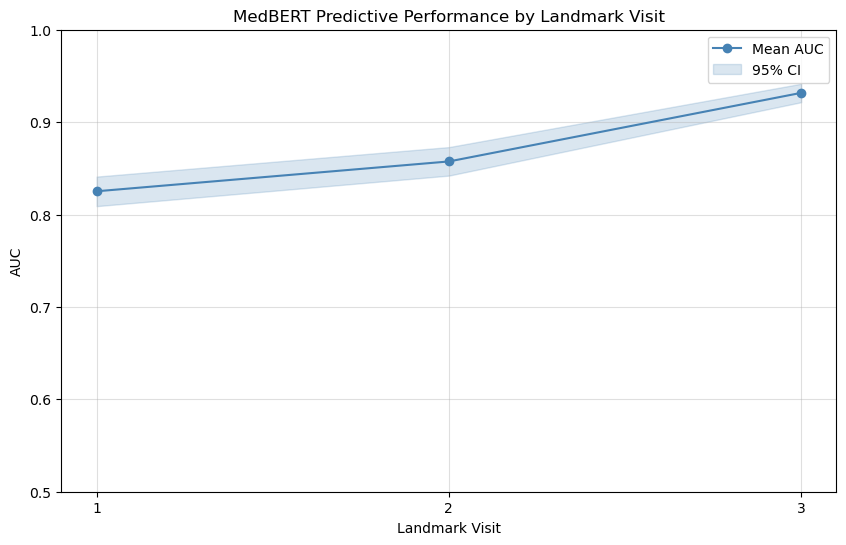

   Landmark (Visit Number)  Number of Patients (Test) Mortality (%)  \
0                        1                       4022         14.4%   
1                        2                       4022         14.4%   
2                        3                       4022         14.4%   

  AUC MedBERT  
0      0.8252  
1      0.8574  
2      0.9317  


In [3]:
class ClinicalDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=512):
        self.encodings = tokenizer(texts, truncation=True, padding=True, max_length=max_length)
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

# Store predictions and labels for confidence intervals
predictions_list = []
labels_list = []

for landmark_visit in range(1, max_visits + 1):
    print(f"Fine-tuning and evaluating at Landmark {landmark_visit}")

    df_subset = df_selected[df_selected['landmark_visit'] == landmark_visit]

    patients = df_subset['subject_id'].unique()

    train_patients, test_patients = train_test_split(
        patients,
        test_size=0.2,
        random_state=SEED,
        stratify=df_subset.groupby('subject_id')['death_in_90days'].max()
    )

    train_df = df_subset[df_subset['subject_id'].isin(train_patients)].copy()
    test_df = df_subset[df_subset['subject_id'].isin(test_patients)].copy()
    
    # Clearly apply the narrative_prompt function
    train_texts = train_df.apply(narrative_prompt, axis=1).tolist()
    train_labels = train_df['death_in_90days'].tolist()

    test_texts = test_df.apply(narrative_prompt, axis=1).tolist()
    test_labels = test_df['death_in_90days'].tolist()

    # train_texts = train_df.apply(lambda row: ' '.join(filter(None, [row['med_text'], row['diag_text'], row['proc_text']])), axis=1).tolist()
    # train_labels = train_df['death_in_90days'].tolist()

    # test_texts = test_df.apply(lambda row: ' '.join(filter(None, [row['med_text'], row['diag_text'], row['proc_text']])), axis=1).tolist()
    # test_labels = test_df['death_in_90days'].tolist()

    train_dataset = ClinicalDataset(train_texts, train_labels, tokenizer)
    test_dataset = ClinicalDataset(test_texts, test_labels, tokenizer)

    train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

    model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(device)

    optimizer = AdamW(model.parameters(), lr=2e-5)
    
    # model.train()
    # for epoch in range(epochs):
    #     total_loss = 0
    #     for batch in train_loader:
    #         optimizer.zero_grad()
    #         inputs = {k: v.to(device) for k, v in batch.items()}
    #         outputs = model(**inputs)
    #         loss = outputs.loss
    #         loss.backward()
    #         optimizer.step()
    #         total_loss += loss.item()
    #     avg_loss = total_loss / len(train_loader)
    #     print(f'Landmark {landmark_visit}, Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

    epochs = 5  # Allow more epochs
    patience = 1  # Stop if no improvement after 3 epochs
    best_val_auc = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        # Training phase
        for batch in train_loader:
            optimizer.zero_grad()
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            loss = outputs.loss
            loss.backward()
            optimizer.step()
            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)

        # Validation phase
        model.eval()
        val_predictions, val_labels = [], []

        with torch.no_grad():
            total_val_loss = 0
            for batch in test_loader:
                inputs = {k: v.to(device) for k, v in batch.items()}
                outputs = model(**inputs)
                val_loss = outputs.loss
                total_val_loss += val_loss.item()
                
                probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
                val_predictions.extend(probs)
                val_labels.extend(batch['labels'].cpu().numpy())

        avg_val_loss = total_val_loss / len(test_loader)
        val_auc = roc_auc_score(val_labels, val_predictions)

        print(f'Epoch {epoch+1}/{epochs} | '
            f'Train Loss: {avg_train_loss:.4f} | '
            f'Validation Loss: {avg_val_loss:.4f} | '
            f'Validation AUC: {val_auc:.4f}')

        # Check early stopping conditions
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            epochs_no_improve = 0
            # Optionally save best model weights:
            torch.save(model.state_dict(), 'best_model.pt')
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after epoch {epoch+1}')
                break

    # Load best model after early stopping:
    model.load_state_dict(torch.load('best_model.pt'))
    
    model.eval()
    predictions, true_labels = [], []

    with torch.no_grad():
        for batch in test_loader:
            inputs = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**inputs)
            probs = torch.softmax(outputs.logits, dim=-1)[:, 1].cpu().numpy()
            predictions.extend(probs)
            true_labels.extend(batch['labels'].cpu().numpy())

    auc = roc_auc_score(true_labels, predictions)
    mortality_rate = np.mean(test_labels) * 100
    num_patients = len(test_df)

    results.append({
        'Landmark (Visit Number)': landmark_visit,
        'Number of Patients (Test)': num_patients,
        'Mortality (%)': f"{mortality_rate:.1f}%",
        'AUC MedBERT': f"{auc:.4f}"
    })

    predictions_list.append(predictions)
    labels_list.append(true_labels)

# Confidence interval calculation
def bootstrap_auc_ci(y_true, y_pred, n_bootstraps=1000, alpha=0.95):
    bootstrapped_scores = []
    rng = np.random.RandomState(SEED)
    for _ in range(n_bootstraps):
        indices = rng.randint(0, len(y_pred), len(y_pred))
        if len(np.unique(np.array(y_true)[indices])) < 2:
            continue
        score = roc_auc_score(np.array(y_true)[indices], np.array(y_pred)[indices])
        bootstrapped_scores.append(score)

    sorted_scores = np.array(bootstrapped_scores)
    sorted_scores.sort()
    lower = sorted_scores[int((1.0 - alpha) / 2 * len(sorted_scores))]
    upper = sorted_scores[int((alpha + (1.0 - alpha) / 2) * len(sorted_scores))]
    return lower, upper

landmark_visits = list(range(1, max_visits + 1))
auc_means = []
ci_lowers = []
ci_uppers = []

for preds, labels in zip(predictions_list, labels_list):
    auc = roc_auc_score(labels, preds)
    ci_lower, ci_upper = bootstrap_auc_ci(labels, preds)
    auc_means.append(auc)
    ci_lowers.append(ci_lower)
    ci_uppers.append(ci_upper)

# Plot AUC with CI
plt.figure(figsize=(10, 6))
plt.plot(landmark_visits, auc_means, marker='o', color='steelblue', label='Mean AUC')
plt.fill_between(landmark_visits, ci_lowers, ci_uppers, color='steelblue', alpha=0.2, label='95% CI')
plt.xticks(landmark_visits)
plt.xlabel('Landmark Visit')
plt.ylabel('AUC')
plt.title('MedBERT Predictive Performance by Landmark Visit')
plt.legend()
plt.grid(alpha=0.4)
plt.ylim([0.5, 1.0])
plt.show()

results_df = pd.DataFrame(results)
print(results_df)
